In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes', 'gymnasium']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact'), 'gymnasium': ('1.2.3', 'gymnasium[toy-text]==1.2.3', 'gymnasium[toy-text]==1.2.3', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Variance Reduction for Policy Gradients

The REINFORCE estimator is unbiased but can have high variance. On FrozenLake, unsuccessful trajectories have zero return and contribute no gradient signal, while successful trajectories can produce large updates. This section derives several variance-reduction methods from the zero-mean score identity: reward-to-go, constant baselines, control variates, and state-dependent baselines. It also distinguishes centering, which changes the estimator, from scaling, which changes its effective step size. We compare five estimators against the exact gradient used in that section.

In [1]:
%matplotlib inline
from d2l import jax as d2l
from flax import nnx
import gymnasium as gym
import jax
from jax import numpy as jnp
import numpy as np
import optax

We retain the deterministic FrozenLake environment, complete-episode horizon, discount $\gamma=0.95$, and tabular softmax policy from that section. Each update uses four episodes so that differences in estimator variance remain visible. We run twenty seeds to characterize the substantial variation between training runs.

In [2]:
gamma, alpha, alpha_v = 0.95, 16.0, 0.1  # discount; SGD step; value step
num_updates, batch_episodes = 150, 4   # small batches, to expose variance
num_seeds = 20                         # with 5, the medians below are noise
env = gym.wrappers.TimeLimit(
    gym.make('FrozenLake-v1', is_slippery=False).env, max_episode_steps=10_000)

## A Zero-Mean Identity

The following identity underlies each variance-reduction method in this section.

### The Zero-Mean Lemma

**Lemma.** For every state $s$, $\ \sum_{a \in \mathcal{A}} \pi_\theta(a \mid s)\ \nabla_\theta \log \pi_\theta(a \mid s) = 0$.

**Proof.** $\sum_a \pi_\theta(a \mid s) \nabla_\theta \log \pi_\theta(a \mid s) = \sum_a \nabla_\theta\, \pi_\theta(a \mid s) = \nabla_\theta \sum_a \pi_\theta(a \mid s) = \nabla_\theta 1 = 0.$ $\blacksquare$

In words: at any state, the score of the sampled action has zero mean. For our softmax policy the lemma can also be read directly off the verified score formula the equation, which sums to zero over actions by inspection; the proof above is the same cancellation stated for every differentiable policy at once.

### The Conditional Version

The useful consequence is slightly stronger. Suppose $c$ is any quantity that is already determined by the time the agent stands at state $s_t$: a reward collected earlier in the trajectory, a constant, or a function of $s_t$ itself. Conditioned on the trajectory prefix $(s_0, a_0, r_0, \ldots, s_t)$, the value $c$ is fixed while the action $a_t$ is still random, and since the policy consults only $s_t$, the inner expectation is the one the lemma covers:

$$E\big[ c\ \nabla_\theta \log \pi_\theta(a_t \mid s_t) \big] = E\Big[ c\ \underbrace{E\big[ \nabla_\theta \log \pi_\theta(a_t \mid s_t) \mid s_0, a_0, \ldots, s_t \big]}_{=\,0 \textrm{ by the lemma}} \Big] = 0.$$

We can therefore multiply any score in the REINFORCE estimator by such a quantity, or subtract such a quantity from its weight, without moving the average. Every tool in this section is an instance of this observation.

## Variance Reduction from the Zero-Mean Identity

The identity supports four modifications: removing past-reward terms, subtracting a constant, choosing a variance-minimizing constant, and subtracting a state-dependent function. Each preserves the expected gradient under its stated dependence conditions.

### Reward-to-Go and Causality

In the REINFORCE estimator, the score at time $t$ is multiplied by the
return $R(\tau_i)$ of the whole trajectory, including rewards collected
before action $a_t^i$. Those earlier rewards cannot depend on that action.
Their product with the time-$t$ score therefore has zero expectation but
can have nonzero variance. Removing these zero-mean terms from
$\nabla_\theta J(\theta)$ leaves

$$\nabla_\theta J(\theta) = E_{\tau \sim P(\cdot;\, \theta)} \Big[ \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t \mid s_t)\ \sum_{t'=t}^{T-1} \gamma^{t'} r_{t'} \Big].$$

The inner sum equals $\gamma^t \hat{G}_t$ where

$$\hat{G}_t = \sum_{t'=t}^{T-1} \gamma^{t'-t}\, r_{t'}$$

is called the reward-to-go from step $t$. It is the discounted return of the trajectory suffix beginning at $s_t$. Implementations commonly omit the leading factor $\gamma^t$ and weight the score by $\hat{G}_t$ alone. This replaces discounted state occupancy with undiscounted occupancy and can change the gradient direction, not only its magnitude. The resulting update is therefore a per-step surrogate rather than an unbiased estimator of the discounted objective's gradient. We distinguish this surrogate from both the exact discounted estimator and the finite-batch centered estimators introduced below. The surrogate is

$$\hat{u} = \frac{1}{n} \sum_{i=1}^n \sum_{t=0}^{T-1} \hat{G}_t^i\ \nabla_\theta \log \pi_\theta(a_t^i \mid s_t^i).$$

This removal follows from causality: the action chosen at time $t$ can influence only rewards from time $t$ onward, so earlier rewards have zero expected product with its score.

In code, reward-to-go requires one backward scan over the batch, restarted at each episode boundary. We implement the general scan for later reuse:

In [3]:
@d2l.add_to_class(d2l.Batch)
def backward_scan(self, x, factor):
    """y_t = x_t + factor * y_{t+1}, restarted at every episode boundary."""
    y = np.zeros_like(x)
    for ep in self.episodes():
        running = 0.0
        for t in reversed(range(ep.start, ep.stop)):
            running = x[t] + factor * running
            y[t] = running
    return y

@d2l.add_to_class(d2l.Batch)
def reward_to_go(self, gamma):
    """G_t: the discounted return of the rest of its episode, by one scan."""
    return self.backward_scan(self.rew, gamma)

The same backward scan will be used for generalized advantage estimation in that section. There it is applied to the temporal-difference errors of that section with decay $\gamma\lambda$. At $\lambda=1$, the resulting sum telescopes to the reward-to-go.

### Baselines

The second use of the identity is subtraction. Any quantity $b$ that does not depend on the action $a_t$, whether a constant or a function $b(s_t)$ of the current state, can be subtracted from the reward-to-go without biasing the estimator:

$$\hat{u} = \frac{1}{n} \sum_{i=1}^n \sum_{t=0}^{T-1} \big( \hat{G}_t^i - b(s_t^i) \big)\ \nabla_\theta \log \pi_\theta(a_t^i \mid s_t^i).$$

Such a $b$ is called a baseline. The extra term is $b(s_t)$ times the score, and we showed above that this has zero mean, so the equation and the equation estimate the same gradient.

On FrozenLake, every reward-to-go is nonnegative. Without a baseline, sampled actions therefore receive only positive weights, with larger increases on more successful trajectories. Subtracting a value near the typical return gives positive weights to better-than-typical continuations and negative weights to worse-than-typical ones. A baseline may be a constant, an empirical mean return, or an estimate of the value function. The mean return is simple but not generally variance minimizing; the optimal constant is derived below and generalized in the exercises.

### Control Variates

Baseline subtraction is an instance of the control-variate method for Monte Carlo estimation.

Suppose the objective is to estimate $E[X]$, and each sample also contains a correlated quantity $Y$ whose expectation is known. For any scalar $c$, define

$$X_c = X - c\, \big( Y - E[Y] \big).$$

Since $E[Y-E[Y]]=0$, the estimator $X_c$ has the same expectation as $X$ for every $c$. Its variance is

$$\mathrm{Var}(X_c) = \mathrm{Var}(X) - 2c\, \mathrm{Cov}(X, Y) + c^2\, \mathrm{Var}(Y),$$

Minimizing this quadratic gives

$$c^* = \frac{\mathrm{Cov}(X, Y)}{\mathrm{Var}(Y)},$$

and substituting $c^*$ back in leaves the variance at $(1 - \mathrm{corr}^2)\, \mathrm{Var}(X)$, where $\mathrm{corr}$ is the correlation between $X$ and $Y$. Strong correlation therefore permits substantial variance reduction: at $\mathrm{corr}=0.9$, the variance falls by a factor of about five, whereas at $\mathrm{corr}=0$ it is unchanged. The quantity $Y$ is called a control variate for $X$.

For a policy gradient, take

$$X = \hat{G}_t\, \nabla_\theta \log \pi_\theta(a_t \mid s_t),$$

and

$$Y = \nabla_\theta \log \pi_\theta(a_t \mid s_t).$$

Here $E[Y\mid s_t]=0$ by the zero-mean lemma, and $X$ is a scalar multiple of $Y$. Setting $c=b(s_t)$ recovers the equation. Thus a baseline is a control variate constructed from the policy score.

This interpretation explains both unbiasedness and the choice of baseline. Any coefficient preserves the mean of a control-variate estimator, while the variance-minimizing coefficient is the covariance-to-variance ratio $c^*$, computed separately for each state. For a vector-valued score, scalar products replace ordinary products and give the score-weighted optimal baseline derived in the exercises. The average return is often effective, but it is not generally optimal. @Greensmith.Bartlett.Baxter.2004 develop this analysis for policy gradients and interpret a value-function critic as a control variate.

![Variance reduction for the one-step problem of the figure. The reward is $R(a)=0.4+2e^{-(a-2)^2/2}$ under $\mathcal{N}(0,1)$, with $E[R]=0.92$ and $\nabla_\mu J=0.52$. (a) Rewards preceding an action have zero expected product with its score, leaving only reward-to-go. (b) The standard deviation of a single-sample gradient estimate decreases from $1.34$ without a baseline to $0.69$ after subtracting the mean reward. The distributions are clipped at the 1st and 95th percentiles. (c) Estimator variance as a function of a constant baseline $b$. The optimum $b^\star=c^*=1.18$ leaves $1-\mathrm{corr}^2=0.23$ of the original variance.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-variance-reduction.svg)

### The Advantage and the Learned Baseline

A natural state-dependent baseline is the value function $V^\pi(s)$. Since $A^\pi(s,a)=Q^\pi(s,a)-V^\pi(s)$ has mean zero under the policy, subtracting $V^{\pi_\theta}(s_t)$ from the reward-to-go makes $\hat G_t-V^{\pi_\theta}(s_t)$ a sample estimate of the advantage. It is positive when the sampled continuation performs better than the policy's average continuation from $s_t$, and negative when it performs worse.

We do not know $V^{\pi_\theta}$, but we can estimate it from the same batch of trajectories. Keep a table $\hat{V}(s)$, and after each batch move the estimate at every visited state toward the reward-to-go observed there,

$$\hat{V}(s_t) \leftarrow \hat{V}(s_t) + \alpha_V \big( \hat{G}_t - \hat{V}(s_t) \big),$$

with a step size $\alpha_V$, its subscript keeping it clear of the policy step $\alpha$. This algorithm is REINFORCE with a baseline [@Williams.1992]. Note that $\hat{V}$ is trained here by regression on Monte Carlo returns, meaning reward-to-go values computed from complete sampled trajectories; in that section, bootstrapped targets will also depend on its predictions, producing an actor--critic method.

## Centering, Scaling, and Normalization

Several implementation choices affect either the estimator or its scale. To distinguish them, we reuse the policy frozen after sixteen updates in that section, together with the exact gradient from the differentiable linear solve. The same solve also provides the exact value function $V^{\pi_\theta}$ used below.

In [4]:
mdp = d2l.TabularMDP.from_gym(env, gamma)
P, r = jnp.asarray(mdp.P), jnp.asarray(mdp.r)
probe = d2l.ActorCritic.tabular(16, 4, rngs=nnx.Rngs(3))
rng = np.random.default_rng(3)
env.reset(seed=3)
for _ in range(16):
    b = d2l.rollout(env, probe.act, 16, rng)
    d2l.policy_step(probe, b, np.repeat(b.episode_returns(gamma),
                                        np.diff(b.ep_ends, prepend=0)))

def V_fn(theta):
    pi = jax.nn.softmax(theta, -1)
    return jnp.linalg.solve(jnp.eye(16) - gamma * jnp.einsum('sa,sat->st',
                                                             pi, P),
                            (pi * r).sum(-1))

theta = probe.policy.embedding[...]
g_exact = np.asarray(jax.grad(lambda th: V_fn(th)[0])(theta)).ravel()
V_pi = np.asarray(V_fn(theta))
print(f'J(theta) = {V_pi[0]:.3f}, |grad J| = {np.linalg.norm(g_exact):.3f}')

J(theta) = 0.313, |grad J| = 0.129


The printed $J(\theta) = 0.313$ matches the fixed intermediate policy from the previous section. The exact $\nabla_\theta J$ provides the reference for the measurements below.

### Batch Centering versus Variance Scaling

A practical variant standardizes the reward-to-go values within each batch. Collect every $\hat{G}_t^i$ in the current batch, compute their mean $\mu$ and standard deviation $\sigma$, and use

$$\tilde{G}_t^i = \frac{\hat{G}_t^i - \mu}{\sigma + 10^{-8}}$$

in place of $\hat{G}_t^i$, where the constant $10^{-8}$ avoids dividing by zero. Subtracting $\mu$ acts as a baseline, with one caveat: $\mu$ is computed from the same batch, so it depends weakly on the sampled actions, and the exact zero-bias argument above holds only up to a correction that vanishes as the batch grows. Dividing by $\sigma + 10^{-8}$ is different in kind: it rescales the update so that its size no longer depends on the scale of the rewards, which reduces sensitivity to changes in reward scale, although it changes the effective step size.

Centering and scaling have different effects. Subtracting $\mu$ changes the relative weights of the samples and can change the direction of the estimate. Dividing by $\sigma+10^{-8}$ multiplies the complete batch estimate by one positive scalar, leaving its direction unchanged. It is therefore a per-batch step-size adjustment rather than a baseline. On FrozenLake, $0\leq\hat{G}_t\leq1$ implies $\sigma\leq1/2$, so normalization increases the step norm by at least a factor of two at a fixed learning rate; the measured factor below is about five. Any performance difference must consequently be interpreted together with the optimizer and effective step size, as in that section and that section.

Two utilities support the remaining experiments: `normalize` implements the equation, and `run_seeds` executes a seeded training generator and stacks its curves. The experiments compute multi-seed results explicitly before plotting.

In [5]:
def normalize(x, eps=1e-8):
    """Center a batch of weights and rescale them to unit spread."""
    return (x - x.mean()) / (x.std() + eps)

def run_seeds(train, num_seeds, **kwargs):
    """Run train(seed, **kwargs), a generator of curve points, per seed."""
    return np.array([list(train(seed, **kwargs)) for seed in range(num_seeds)])

### The Leave-One-Out Baseline

Leave-one-out centering removes the self-dependence of the batch mean $\mu$. For each trajectory, define a baseline from the *other* trajectories in the batch,

$$b_i = \frac{1}{n-1} \sum_{j \neq i} R(\tau_j),$$

so that $b_i$ is independent of trajectory $i$ conditional on the other
trajectories. The conditional zero-mean identity therefore applies with no
correction term: the estimator is unbiased at every batch size. Moreover,

$$R_i-b_i=\frac{n}{n-1}(R_i-\mu),$$

so leave-one-out centering differs from ordinary batch centering only by
the constant $n/(n-1)$. Plain centering with per-trajectory weights thus
shrinks the mean estimator by $(n-1)/n$. We verify both statements on a
small decision problem that can be enumerated exactly: two states visited
in order, two actions at each state, table-based rewards, and analytic
scores from the equation.

In [6]:
def leave_one_out(R):
    """b_i = the mean of the other n - 1 returns: n/(n-1) times centering."""
    return (R - R.mean()) * len(R) / (len(R) - 1)

rng = np.random.default_rng(0)
th = rng.standard_normal((2, 2))               # a generic two-state table
pi2 = np.exp(th) / np.exp(th).sum(1, keepdims=True)
r2 = np.array([[0.3, 1.0], [0.6, 0.1]])        # r[s, a]; s0 -> s1 -> done
trajs = [(a0, a1) for a0 in range(2) for a1 in range(2)]
p = np.array([pi2[0, a0] * pi2[1, a1] for a0, a1 in trajs])
R = np.array([r2[0, a0] + r2[1, a1] for a0, a1 in trajs])
S = np.zeros((4, 2, 2))                        # the score of each trajectory
for i, (a0, a1) in enumerate(trajs):
    S[i] = -pi2
    S[i, 0, a0] += 1
    S[i, 1, a1] += 1
g = (p[:, None, None] * R[:, None, None] * S).sum(0)    # exact gradient
u_loo = u_cen = 0.0
for i in range(4):
    for j in range(4):                         # every batch of n = 2
        w, wc = leave_one_out(R[[i, j]]), R[[i, j]] - R[[i, j]].mean()
        u_loo += p[i] * p[j] * (w[0] * S[i] + w[1] * S[j]) / 2
        u_cen += p[i] * p[j] * (wc[0] * S[i] + wc[1] * S[j]) / 2
print(f'E[leave-one-out] equals the exact gradient: {np.allclose(u_loo, g)}')
print(f'E[centered] equals (n-1)/n of it:           {np.allclose(u_cen, g / 2)}')

E[leave-one-out] equals the exact gradient: True
E[centered] equals (n-1)/n of it:           True


Both identities hold to machine precision. The same estimator is used for language-model post-training under the name RLOO: sample $n$ responses to a prompt and weight each response by its reward minus the mean reward of the other $n-1$ responses [@Ahmadian.Cremer.Galle.ea.2024].

### Summing over Episodes of Different Lengths

The normalization of a summed loss determines the resulting estimator. The double sum in the equation ranges over episodes and steps. Dividing by the number of episodes $n$ gives the estimator in that equation. Dividing by the total number of steps rescales each batch by its realized mean episode length, which varies across batches and may correlate with performance. Dividing each episode's contribution by its own length can also change the gradient direction because episodes receive different relative weights. Division by a fixed constant changes only the overall scale.

We compare these four choices on a FrozenLake batch whose episode lengths differ:

In [7]:
pi_np = np.exp(probe.log_prob_np(np.repeat(np.arange(16), 4),
                                 np.tile(np.arange(4), 16))).reshape(16, 4)
b = d2l.rollout(env, probe.act, 4, np.random.default_rng(6))
G, T = b.reward_to_go(gamma), np.diff(b.ep_ends, prepend=0)
print(f'episode lengths {T}, successes {int(b.rew.sum())}')

def agg(scale):   # sum_t scale_t * G_t * score_t, via eq_softmax_score
    u = np.zeros((16, 4))
    np.add.at(u, b.obs,
              (G * scale)[:, None] * (np.eye(4)[b.act] - pi_np[b.obs]))
    return u.ravel()

grads = {'episodes': agg(np.full(len(b), 1 / len(T))),
         'own length': agg(np.repeat(1 / T, T) / len(T)),
         'total steps': agg(np.full(len(b), 1 / len(b))),
         'a constant': agg(np.full(len(b), 1 / 32))}
for k, u in grads.items():
    cos = u @ grads['episodes'] / (np.linalg.norm(u)
                                   * np.linalg.norm(grads['episodes']))
    print(f'{k:>12}: |grad| = {np.linalg.norm(u):.3f}, '
          f'cos to episodes = {cos:.3f}')

episode lengths [ 8 20  8 11], successes 3
    episodes: |grad| = 0.868, cos to episodes = 1.000
  own length: |grad| = 0.082, cos to episodes = 0.937
 total steps: |grad| = 0.074, cos to episodes = 1.000
  a constant: |grad| = 0.109, cos to episodes = 1.000


Three of the four gradients are exactly parallel, at sizes an order of magnitude apart; the per-own-length variant tilts away from the rest. In order, these are the per-trajectory estimator, the per-response length normalization, the token-level loss, and the fixed-constant normalization of the LLM post-training literature. The choice of divisor differs among language-model objectives: GRPO normalizes each response by its own length, whereas the "Dr. GRPO" modification uses a constant because only batchwise rescaling preserves the estimator direction. The following four-episode example shows the resulting gradients.

### Normalized Returns and GRPO

Group Relative Policy Optimization (GRPO) [@Shao.Wang.Zhu.ea.2024] samples a *group* of $K$ responses to the same prompt, assigns each response a reward $r_j$, and weights the score function with

$$A_j = \frac{r_j - \mu}{\sigma + 10^{-8}},$$

where $\mu$ and $\sigma$ are the mean and standard deviation within the group. This is the equation, with a prompt corresponding to a start state and its responses to a batch of trajectories. The group mean provides a prompt-specific baseline without requiring a separate value network, and the group standard deviation normalizes reward scales across prompts. Division by $\sigma$ also changes the effective step size separately for each prompt; it is therefore not merely baseline subtraction. The remaining components of GRPO are discussed in that section and that section.

## Empirical Comparison of Gradient Estimators

We next compare the estimators at a fixed policy and during training.

### Five Gradient Estimators

The methods introduced above differ in the quantity multiplying the score at step $t$:

1. **Trajectory return** $R(\tau)$: unbiased the equation, and the noisiest.
2. **Reward-to-go** $\hat{G}_t$: removes terms with zero expectation; it is exactly unbiased when the $\gamma^t$ factor is retained. Our implementation omits that factor and therefore uses the per-step surrogate described above.
3. **Constant baseline** $\hat{G}_t - b$: unbiased for every $b$; the best constant is the control-variate optimum $c^*$.
4. **State baseline** $\hat{G}_t - b(s_t)$: unbiased; the natural target for $b$ is $V^{\pi_\theta}$.
5. **Leave-one-out**: exactly unbiased, batch coupling included.
6. **A learned critic** $\hat{V}(s)$: baseline subtraction remains unbiased when the critic only replaces $b(s_t)$; using critic predictions inside bootstrapped targets introduces the approximation studied in that section.
7. **Generalized advantage estimation**: a coefficient $\lambda$ interpolating between reward-to-go and a bootstrapped critic (that section, that section).

Before training, we hold $\theta$ fixed, draw 200 batches of the training batch size, and compute each per-episode estimator through the score identity. Comparison with the exact gradient measures both the estimator mean and its sampling variance. For the state baseline we can afford here what training cannot: the exact $V^{\pi_\theta}$ from the linear solve.

In [8]:
def estimate(b, w):
    """One draw of the estimator: weighted scores, averaged over episodes."""
    u = np.zeros((16, 4))
    np.add.at(u, b.obs, w[:, None] * (np.eye(4)[b.act] - pi_np[b.obs]))
    return u.ravel() / len(b.ep_ends)

weightings = {
    'return': lambda b, G: np.repeat(b.episode_returns(gamma),
                                     np.diff(b.ep_ends, prepend=0)),
    'reward-to-go': lambda b, G: G,
    'centered': lambda b, G: G - G.mean(),
    'normalized': lambda b, G: normalize(G),
    'exact baseline': lambda b, G: G - V_pi[b.obs]}
rng, draws = np.random.default_rng(4), {k: [] for k in weightings}
for _ in range(200):
    b = d2l.rollout(env, probe.act, 4, rng)
    G = b.reward_to_go(gamma)
    for k, fn in weightings.items():
        draws[k].append(estimate(b, fn(b, G)))
for k, u in draws.items():
    u = np.stack(u)
    m = u.mean(axis=0)
    cos = m @ g_exact / (np.linalg.norm(m) * np.linalg.norm(g_exact))
    rel = ((u - m) ** 2).sum(axis=1).mean() / (m ** 2).sum()
    print(f'{k:>14}: cos(mean, exact) = {cos:.2f}, '
          f'relative variance = {rel:6.1f}')

        return: cos(mean, exact) = 0.98, relative variance =   11.1
  reward-to-go: cos(mean, exact) = 0.97, relative variance =   10.6
      centered: cos(mean, exact) = 0.98, relative variance =    7.1
    normalized: cos(mean, exact) = 0.97, relative variance =    6.9
exact baseline: cos(mean, exact) = 0.98, relative variance =    5.3


The cosine column checks whether the sample means align with the exact gradient. Cosine similarity cannot detect magnitude errors or errors parallel to the true gradient, but all five estimators agree within the resolution of these 200 draws. The variance measurements show that centering reduces relative variance by about one third and the exact state baseline nearly halves it. Dividing by $\sigma$ adds little variance reduction beyond centering, consistent with its interpretation as a step-size adjustment. Reward-to-go provides only a small improvement here because FrozenLake has a single terminal reward and therefore few past rewards to remove.

We compare the five variants. They share the same data generator and differ only in the weights passed to `policy_step`. We use plain SGD because Adam would partially normalize parameter-wise scale differences and make the effects studied here harder to interpret. Every run maintains the same value table, although only the learned-baseline variant uses it. At each update we record success rate, parameter-step norm, and policy entropy.

In [9]:
def table(ac):
    """The policy's preference table, copied out to numpy."""
    return np.asarray(ac.policy.embedding[...])

def entropy(ac):
    """Mean policy entropy over the sixteen states, in nats."""
    logp = ac.log_prob_np(np.repeat(np.arange(16), 4),
                          np.tile(np.arange(4), 16))
    return float(-(np.exp(logp) * logp).sum() / 16)

In [10]:
def train(seed, variant):
    """Five REINFORCE variants; they differ in one line, the weight."""
    rng, V = np.random.default_rng(seed), np.zeros(16, np.float32)
    ac = d2l.ActorCritic.tabular(16, 4, rngs=nnx.Rngs(seed))
    ac.opt_pi = nnx.Optimizer(ac.policy, optax.sgd(alpha), wrt=nnx.Param)
    env.reset(seed=seed)
    for _ in range(num_updates):
        batch = d2l.rollout(env, ac.act, batch_episodes, rng)
        G = batch.reward_to_go(gamma)
        w = {'return': np.repeat(batch.episode_returns(gamma),
                                 np.diff(batch.ep_ends, prepend=0)),
             'reward-to-go': G,
             'centered': G - G.mean(),
             'normalized': normalize(G),
             'learned baseline': G - V[batch.obs]}[variant]
        before = table(ac)
        d2l.policy_step(ac, batch, w)
        for s, g in zip(batch.obs, G):     # eq_value_baseline, every arm
            V[s] += alpha_v * (g - V[s])
        yield (float(batch.episode_returns().mean()),
               float(np.linalg.norm(table(ac) - before)), entropy(ac))

We run five variants with twenty seeds each; `runs[v]` has shape (seeds, updates, 3):

In [11]:
variants = ['return', 'reward-to-go', 'centered', 'normalized',
            'learned baseline']
runs = {v: run_seeds(train, num_seeds, variant=v) for v in variants}

The success-rate column, smoothed over a ten-update window, with each band spanning the seed minimum to maximum around the seed median:

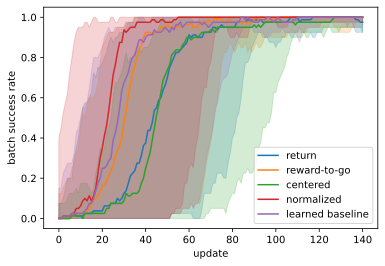

In [12]:
d2l.plot_curves({v: r[:, :, 0] for v, r in runs.items()}, xlabel='update',
                ylabel='batch success rate', smooth=10)

We report performance and parameter-step norms together because both affect the observed ordering:

In [13]:
def to90(curve):
    """First update whose trailing 10-update mean success reaches 0.9."""
    hit = np.convolve(curve, np.ones(10) / 10, 'valid') >= 0.9
    return hit.argmax() if hit.any() else len(curve)

for v, r in runs.items():
    reach = np.array([to90(c) for c in r[:, :, 0]])
    print(f'{v:>16}: updates to 90%: median {np.median(reach):5.1f}, '
          f'fastest {reach.min():3d}, slowest {reach.max():3d}')
    print(f'{"":>16}  mean |step| over the first 40 updates: '
          f'{r[:, :40, 1].mean():.2f}')

          return: updates to 90%: median  60.0, fastest  26, slowest  92
                  mean |step| over the first 40 updates: 0.20
    reward-to-go: updates to 90%: median  40.0, fastest  22, slowest  95
                  mean |step| over the first 40 updates: 0.38
        centered: updates to 90%: median  58.0, fastest  43, slowest 108
                  mean |step| over the first 40 updates: 0.15
      normalized: updates to 90%: median  30.0, fastest   8, slowest  72
                  mean |step| over the first 40 updates: 0.76
learned baseline: updates to 90%: median  40.5, fastest  22, slowest  84
                  mean |step| over the first 40 updates: 0.32


The plain trajectory-return estimator is the slowest in this experiment, with median runs requiring roughly 50--70 updates to maintain 90% batch success. Reward-to-go reduces the median by about one third. The learned baseline performs similarly to reward-to-go, with differences smaller than the variation across seeds. Sparse rewards explain part of this result: the value estimate remains near zero until the policy has reached the goal several times, so the learned-baseline update initially resembles reward-to-go. Centering reduces the frozen-policy variance but has little effect on the median training time.

Normalization reaches 90% success in roughly half as many updates as the plain estimator, but it also produces much larger parameter steps. At the shared learning rate, its steps are about five times larger than those of the centered estimator and about twice as large as those of reward-to-go. Reward-to-go likewise increases the average weight scale relative to the full trajectory return on this environment. Consequently, the training ordering reflects both estimator variance and effective step size. The table reports both quantities, and exercise 1 repeats the comparison after matching their scales.

The runs also record policy entropy. Each method starts at the uniform policy's entropy of $\ln 4 \approx 1.39$ nats and decreases toward roughly $0.8$ as the policy becomes more concentrated. Methods with faster initial improvement reduce entropy earlier. The constrained updates in that section provide explicit control over this change.

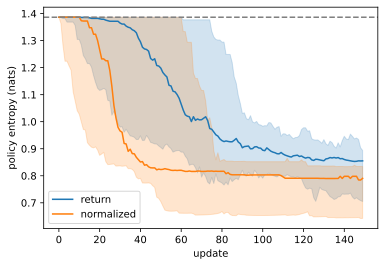

In [14]:
d2l.plot_curves({v: runs[v][:, :, 2] for v in ('return', 'normalized')},
                xlabel='update', ylabel='policy entropy (nats)',
                reference=np.log(4))

### Reading the Comparison across Seeds

The variation across seeds limits the precision with which the methods can be compared.

> **Variation across seeds.** The uncertainty bands are wide. Within one variant, the slowest seed can require more than twice as many updates as the fastest seed to reach 90% success. Comparing selected individual runs could therefore reverse the apparent ordering of the methods. We report medians and ranges over twenty seeds and keep the hyperparameters matched across variants, following the evaluation recommendations in [@Henderson.Islam.Bachman.ea.2018; @Agarwal.Schwarzer.Castro.ea.2021; @Engstrom.Ilyas.Santurkar.ea.2020].

The leave-one-out calculation is framework independent. Measurements that use framework objects agree across the two implementations to the reported precision rather than necessarily to every digit. The environment also matters: FrozenLake's terminal-only reward reduces the effect of reward-to-go, and denser rewards or longer horizons could change both the numerical results and parts of the ordering. For this reason, the comparison reports gradient variance and parameter-step norms together.

## Summary

The score function has zero conditional mean. This identity permits the removal of rewards that precede an action and the subtraction of action-independent baselines without changing the expected gradient. Constant control variates and state-dependent value baselines reduce variance, while reward-to-go removes terms that cannot be influenced by the current action. Batch centering introduces a finite-sample shrinkage that leave-one-out centering removes. Dividing by the batch standard deviation instead changes the effective step size and should be evaluated separately from variance reduction. The empirical comparison confirms these distinctions and reports parameter-step norms alongside training performance.

The implementations add `Batch.backward_scan`, `Batch.reward_to_go`, `normalize`, and `run_seeds` to the shared library.

**Experimental scope.** The variance comparison probes one intermediate policy with 200 batches of four episodes. Different policies change the numerical variances, although the ordering is stable in these experiments. Training results use twenty seeds, and their spreads are often wider than the gaps between methods. FrozenLake's sparse terminal reward limits the benefit of reward-to-go, while plain SGD makes differences in effective step size visible.

## Exercises

1. [short-code] *The step-size confound, quantified.* Rerun the five arms with
   the normalized arm's learning rate divided by its measured mean
   $1/(\sigma + 10^{-8})$: log $\sigma$ per batch during a run of `train`,
   average $1/(\sigma + 10^{-8})$ over the batches that contained any signal,
   and scale $\alpha$ down by that factor for the normalized arm only. Does the
   ordering survive, and which arm does the normalized variant now resemble?
1. [short-code] *Measure the variance you claim to reduce.* Freeze the
   parameters at a partially trained $\theta$. Draw 200 independent batches
   and, for each of the five estimators the section compares, record the
   sample covariance of $\hat{u}$ and report its trace. Does the ordering
   match the ordering of the learning curves, and is the ratio between the
   best and the worst as large as the curves suggested?
1. [conceptual] *The variance-optimal baseline.* For a single state and a
   constant baseline $b$, the variance of the estimator is minimized not by
   the average return but by the weighted average
   $b^* = E[\|\nabla_\theta \log \pi_\theta(a \mid s)\|^2 \hat{G}] /
   E[\|\nabla_\theta \log \pi_\theta(a \mid s)\|^2]$.
   Derive this by differentiating the variance with respect to $b$, and check
   that it is the optimal coefficient $c^*$ of the equation
   carried over to the vector-valued score.
1. [short-code] *Baseline step size.* Vary $\alpha_V$ in the equation
   over $\{0.01, 0.1, 0.5, 1.0\}$. How sensitive is the learned-baseline variant,
   and what exactly goes wrong at $\alpha_V = 1$? Relate the failure to what
   $\hat{V}$ is being asked to average over.
1. [short-code] *The group-relative baseline in two lines.* Replace the weight
   in the equation by
   $(R(\tau_i) - \mu) / (\sigma + 10^{-8})$, applied to every step of
   trajectory $i$, where $\mu$ and $\sigma$ are the mean and standard deviation
   of the returns *within the batch*. This is the advantage estimate of GRPO,
   with the batch playing the role of the group. Before running it: what happens
   at batch size one, and why? Now run it at batch sizes $\{1, 2, 4, 16\}$ and
   confirm.
1. [conceptual] *What dividing by sigma costs.* The group standard deviation in
   the previous exercise makes advantages comparable across prompts. Consider
   two prompts, one on which the policy succeeds half the time and one on which
   it succeeds nine times in ten. Compute $\sigma$ for each under a binary
   reward, and say which prompt's gradient is amplified. Is that the weighting
   you want? (This is the objection that the "Dr. GRPO" line of work raises
   against dividing by $\sigma$.)

[Discussions](https://d2l.discourse.group/)